In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

# Set time period to be plotted in terms of number of days to crisis.
# -60 means 60 days before crisis date.
earliest_day = -60 
latest_day = -1

## Load data

In [7]:
# Load Levy stable parameter estimates
alpha_df = pd.read_csv('Results/alpha.csv')
beta_df = pd.read_csv('Results/beta.csv')

# Filter time period to study and sort data chronologically
alpha_filtered = alpha_df[(alpha_df['Days to crisis'] >= earliest_day) & (alpha_df['Days to crisis'] <= latest_day)].sort_values(by='Days to crisis')
beta_filtered = beta_df[(beta_df['Days to crisis'] >= earliest_day) & (beta_df['Days to crisis'] <= latest_day)].sort_values(by='Days to crisis')

# Load prices
# S&P 500
sp500_df = pd.read_csv('Data/S&P500/SP500_2016-2024_daily.csv')
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'], format='mixed').dt.strftime('%Y-%m-%d')
sp500_df = sp500_df.sort_values(by='Date').reset_index(drop=True)
sp500_df['Price'] = sp500_df['Close/Last']

# NIKKEI
nikkei_df = pd.read_csv('Data/NIKKEI/Nikkei225_2010-2024 daily.csv')
nikkei_df['Date'] = pd.to_datetime(nikkei_df['Date'], format='mixed').dt.strftime('%Y-%m-%d')
nikkei_df = nikkei_df.sort_values(by='Date').reset_index(drop=True)
nikkei_df['Price'] = pd.to_numeric(nikkei_df['Price'].astype(str).str.replace(',', ''), errors='coerce')

# Bitcoin
months = ['2022-01','2022-02','2022-03','2022-04','2022-05','2022-06',
          '2022-07','2022-08','2022-09','2022-10','2022-11','2022-12',
          '2023-01','2023-02','2023-03','2023-04','2023-05','2023-06',
          '2023-07','2023-08','2023-09','2023-10','2023-11','2023-12',
          '2024-01','2024-02','2024-03','2024-04','2024-05','2024-06',
          '2024-07','2024-08','2024-09','2024-10','2024-11','2024-12',
          '2025-01','2025-02','2025-03','2025-04','2025-05','2025-06',
          '2025-07','2025-08','2025-09','2025-10','2025-11','2025-12',
          '2026-01','2026-02','2026-03','2026-04','2026-05','2026-06']
btc_dfs = [pd.read_csv(f'Data/Bitcoin/BTCUSDT-1d-{m}.csv', header=None) for m in months]
btc_df = pd.concat(btc_dfs, ignore_index=True)[[6, 4]]
btc_df.columns = ['Timestamp', 'Price']
dates = []
for ts in btc_df['Timestamp']:
    if ts < 1e13:
        dates.append(datetime.fromtimestamp(ts / 1e3).date().strftime("%Y-%m-%d"))
    else:
        dates.append(datetime.fromtimestamp(ts / 1e6).date().strftime("%Y-%m-%d"))
btc_df['Date'] = dates
btc_df = btc_df[['Date', 'Price']]

# Map column keywords to DataFrames
datasets = {
    'S&P 500': sp500_df,
    'NIKKEI': nikkei_df,
    'Bitcoin': btc_df
}

def get_prices(crisistitle):
    """
    Get prices from crisis title.
    """
    parts = crisistitle.rsplit('_', 1)
    asset_name = parts[0]
    raw_date = parts[1]
    crisis_date = pd.to_datetime(raw_date, format='mixed').strftime('%Y-%m-%d')

    return datasets[asset_name], crisis_date

print("Loaded data.")

Loaded data.


## Plotting

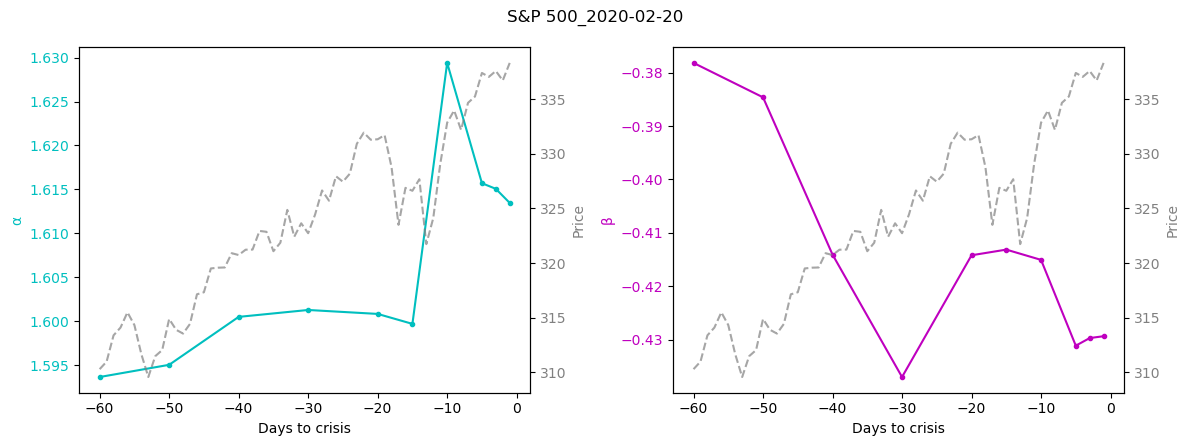

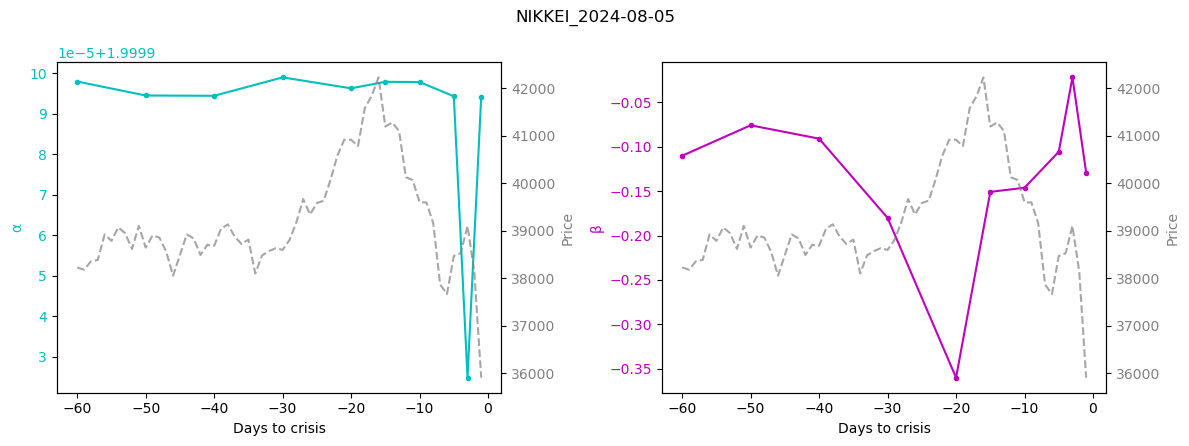

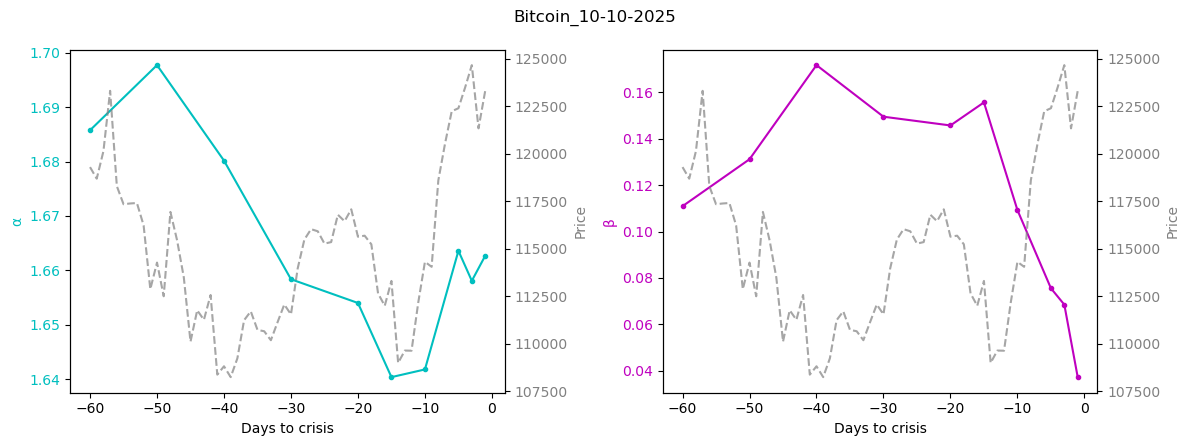

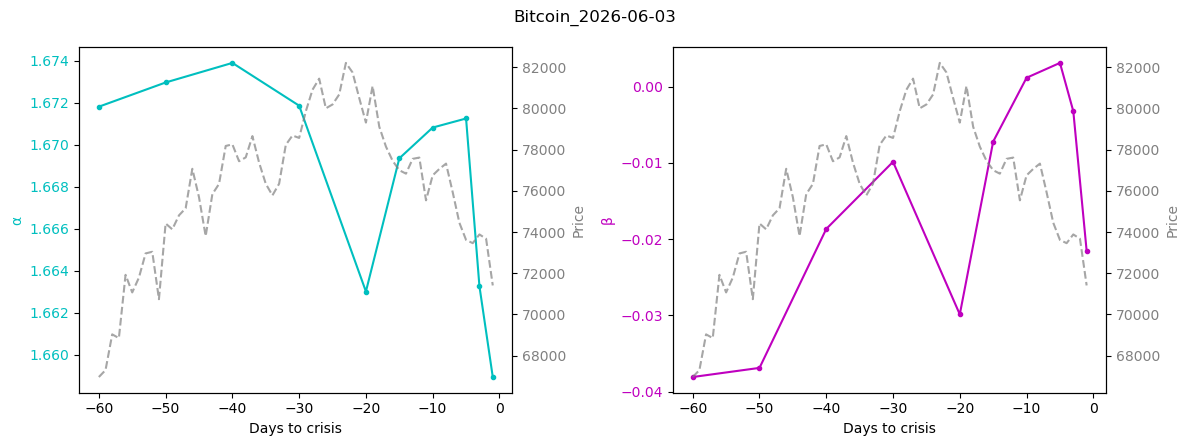

In [10]:
for crisistitle in alpha_filtered.columns[1:]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Automatically get asset DataFrame and crisis date from crisistitle
    data_df, cdate = get_prices(crisistitle)
    c_idx = np.where(data_df['Date'] == cdate)[0][0]

    # Extract prices
    days_range = list(range(earliest_day, latest_day + 1))
    prices = data_df['Price'].iloc[c_idx + earliest_day : c_idx + latest_day + 1].values

    # Alpha & price
    crisis_alpha = alpha_filtered[['Days to crisis', crisistitle]].dropna()
    l1 = ax1.plot(crisis_alpha['Days to crisis'], crisis_alpha[crisistitle], color='c', marker='.', label='α')
    ax1.set_xlabel('Days to crisis')
    ax1.set_ylabel('α', color='c')
    ax1.tick_params(axis='y', labelcolor='c')

    ax1_twin = ax1.twinx()
    l2 = ax1_twin.plot(days_range, prices, color='gray', linestyle='--', alpha=0.7, label='Price')
    ax1_twin.set_ylabel('Price', color='gray')
    ax1_twin.tick_params(axis='y', labelcolor='gray')

    lines1 = l1 + l2
    labels1 = [l.get_label() for l in lines1]

    # Beta & price
    crisis_beta = beta_filtered[['Days to crisis', crisistitle]].dropna()
    l3 = ax2.plot(crisis_beta['Days to crisis'], crisis_beta[crisistitle], color='m', marker='.', label='β')
    ax2.set_xlabel('Days to crisis')
    ax2.set_ylabel('β', color='m')
    ax2.tick_params(axis='y', labelcolor='m')

    ax2_twin = ax2.twinx()
    l4 = ax2_twin.plot(days_range, prices, color='gray', linestyle='--', alpha=0.7, label='Price')
    ax2_twin.set_ylabel('Price', color='gray')
    ax2_twin.tick_params(axis='y', labelcolor='gray')

    lines2 = l3 + l4
    labels2 = [l.get_label() for l in lines2]

    fig.suptitle(crisistitle)
    plt.tight_layout()
    plt.show()
